In [1]:
import pandas as pd
df = pd.read_csv('data_cleaning_finale_vader_3.csv')



In [2]:
                                        # """Transformer le texte en une représentation numérique(vectorisation TF-IDF)"""
             
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import dump


tfidf_v = TfidfVectorizer()

X = tfidf_v.fit_transform(df['content'].values.astype('U'))
y = df['sentiment_vader']



# Sauvegarder le TfidfVectorizer
#dump(tfidf_v, 'tfidf_vader.pkl')



In [4]:
                                            #"""Diviser les données en ensembles d'entraînement et de test"""

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
                                            #"""Entrainement du modèle RandomForestClassifier"""

from sklearn.ensemble import RandomForestClassifier
from joblib import dump


classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)

y_pred_RandomForest = classifier.predict(X_test)

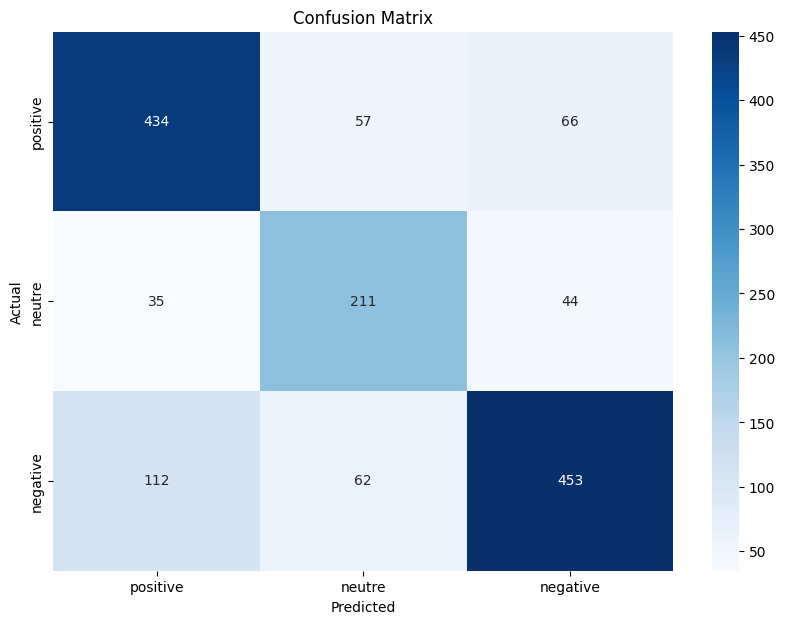

In [6]:
                                    #"""Visualisation de la matrice de confusion""" 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns 


conf_matrix = confusion_matrix(y_test, y_pred_RandomForest)
class_labels = ['positive', 'neutre', 'negative']


# Afficher la matrice de confusion 
plt.figure(figsize=(10, 7)) 
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [7]:
                                        # """Mesures d'évaluation du modèle """

from sklearn.metrics import accuracy_score, classification_report


accuracy = accuracy_score(y_test, y_pred_RandomForest)
print(f'Accuracy: {accuracy}')


print(classification_report(y_test, y_pred_RandomForest))

Accuracy: 0.7449118046132972
              precision    recall  f1-score   support

   Negative        0.75      0.78      0.76       557
    Neutral        0.64      0.73      0.68       290
   Positive        0.80      0.72      0.76       627

    accuracy                           0.74      1474
   macro avg       0.73      0.74      0.73      1474
weighted avg       0.75      0.74      0.75      1474



In [8]:
                                    #"""Entrainement du modèle PassiveAggressiveClassifier"""

from sklearn.linear_model import PassiveAggressiveClassifier
import joblib


pac = PassiveAggressiveClassifier(max_iter=500, random_state=42)
pac.fit(X_train, y_train)

y_pred_PassiveAggressive = pac.predict(X_test)


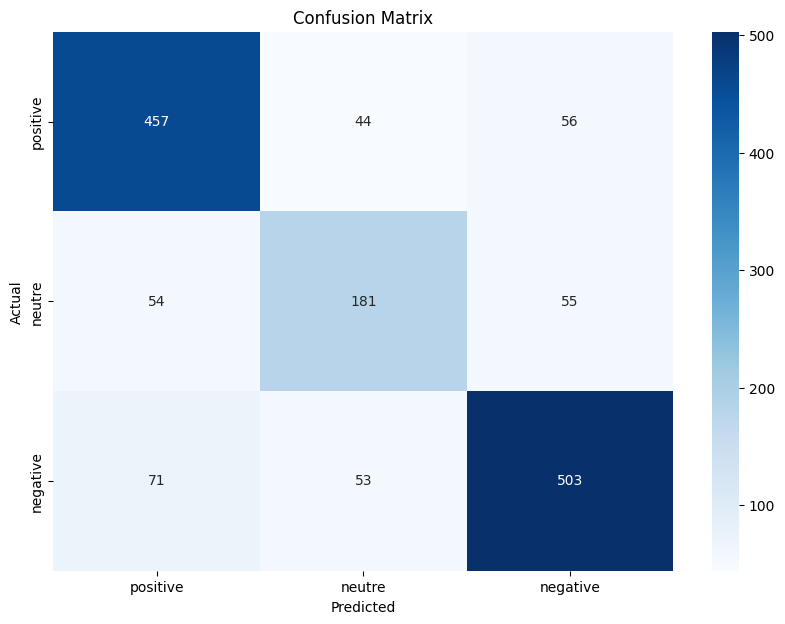

In [9]:
                             #"""Visualisation de la matrice de confusion""" 

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns 


conf_matrix = confusion_matrix(y_test, y_pred_PassiveAggressive)
class_labels = ['positive', 'neutre', 'negative']


# Afficher la matrice de confusion 
plt.figure(figsize=(10, 7)) 
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
                                        # """Mesures d'évaluation du modèle """

from sklearn.metrics import accuracy_score, classification_report


accuracy = accuracy_score(y_test, y_pred_PassiveAggressive)
print(f'Accuracy: {accuracy}')


print(classification_report(y_test, y_pred_PassiveAggressive))

Accuracy: 0.7740841248303935
              precision    recall  f1-score   support

   Negative        0.79      0.82      0.80       557
    Neutral        0.65      0.62      0.64       290
   Positive        0.82      0.80      0.81       627

    accuracy                           0.77      1474
   macro avg       0.75      0.75      0.75      1474
weighted avg       0.77      0.77      0.77      1474



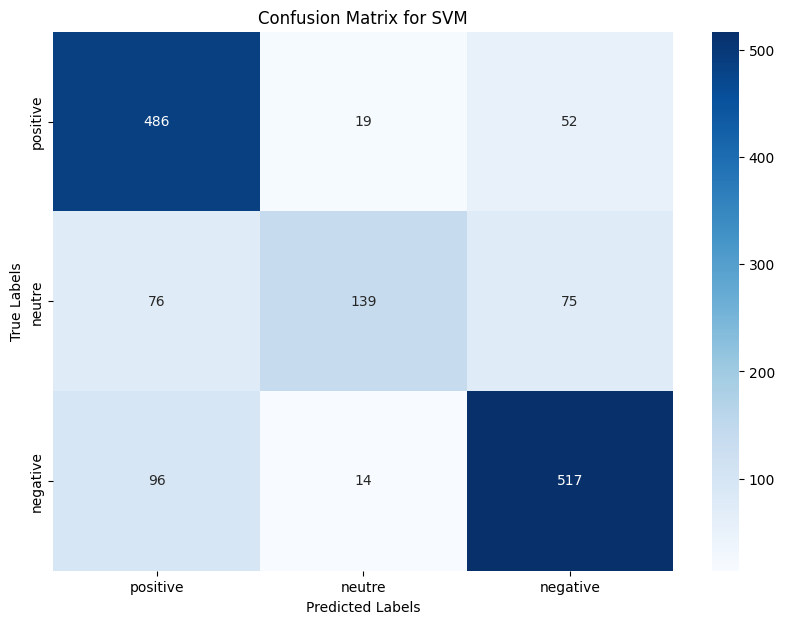

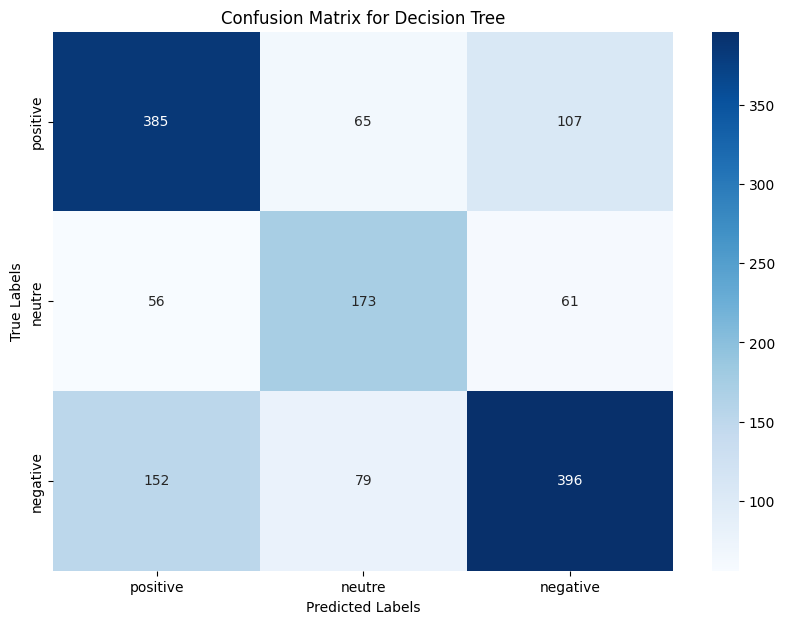

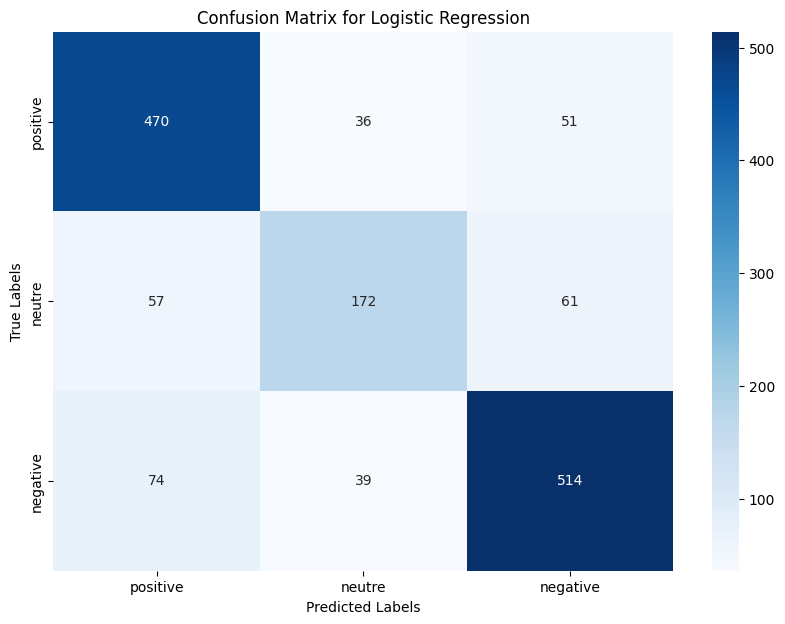

Results for SVM:
  Best Parameters: {'C': 10, 'kernel': 'rbf'}
  Accuracy: 0.7747625508819539
  Precision: 0.779588986020217
  Recall: 0.7747625508819539
  F1 Score: 0.7667483968553545

Results for Decision Tree:
  Best Parameters: {'max_depth': None, 'min_samples_split': 2}
  Accuracy: 0.6472184531886025
  Precision: 0.6513747255757816
  Recall: 0.6472184531886025
  F1 Score: 0.6480323656419564

Results for Logistic Regression:
  Best Parameters: {'C': 10}
  Accuracy: 0.7842605156037992
  Precision: 0.7817877125484239
  Recall: 0.7842605156037992
  F1 Score: 0.7817670630187776



In [11]:
                                        #  """Recherche exhaustive sur les hyperparamètres avec GridSearchCV """


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Dictionnaire contenant les modèles à comparer
models = {
    'SVM': SVC(),
    'Decision Tree': DecisionTreeClassifier(),
    'Logistic Regression': LogisticRegression(max_iter=1000)
}

results = {}

for model_name, model in models.items():
    
    if model_name == 'SVM':
        param_grid = {'C': [0.1, 1, 10], 'kernel': ['poly', 'rbf']}
    elif model_name == 'Decision Tree':
        param_grid = {'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10]}
    elif model_name == 'Logistic Regression':
        param_grid = {'C': [0.1, 1, 10]}

    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    
    results[model_name] = {
        'Best Parameters': grid_search.best_params_,
        'Accuracy': accuracy,
        'Precision': report['weighted avg']['precision'],
        'Recall': report['weighted avg']['recall'],
        'F1 Score': report['weighted avg']['f1-score']
    }

    
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_labels = ['positive', 'neutre', 'negative']

    
    plt.figure(figsize=(10, 7))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

# Afficher les résultats des performances pour chaque modèle.
for model_name, metrics in results.items():
    print(f"Results for {model_name}:")
    for metric, value in metrics.items():
        print(f"  {metric}: {value}")
    print()


In [12]:
                                #"""Entrainement du modèle SVm"""


from sklearn.svm import SVC

svm_model = SVC(C=10, kernel='rbf')
svm_model.fit(X_train, y_train)

predictions = svm_model.predict(X_test)

In [13]:
                                    #"""Entrainement du modèle DecisionTreeClassifier"""

from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(max_depth=None, min_samples_split=2)
tree_model.fit(X_train, y_train)

predictions_DecisionTree = tree_model.predict(X_test)

In [14]:
                                #"""Entrainement du modèle LogisticRegression"""

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(C=10)
logistic_model.fit(X_train, y_train)

predictions_LogisticRegression = logistic_model.predict(X_test)

In [16]:
                                   #Tester les modèles sur l'ensemble des données de validation.
import pandas as pd
from sklearn.metrics import accuracy_score


test_data = pd.read_csv('data_validation_test.csv')


X_test = test_data['content']
X_test = X_test.fillna('')
y_test = test_data['sentiment_vader']

X_test_tfidf = tfidf_v.transform(X_test)


y_pred_random_test = classifier.predict(X_test_tfidf)
y_pred_pac_test = pac.predict(X_test_tfidf)
y_pred_svm_testy =svm_model.predict(X_test_tfidf)
y_pred_tree_testy =tree_model.predict(X_test_tfidf)
y_pred_logistic_testy =logistic_model.predict(X_test_tfidf)


accuracy_random = accuracy_score(y_test, y_pred_random_test)
print(f'Accuracy random : {accuracy_random}')

accuracy_pac = accuracy_score(y_test, y_pred_pac_test)
print(f'Accuracy passive: {accuracy_pac}')

accuracy_svm = accuracy_score(y_test, y_pred_svm_testy )
print(f'Accuracy svm: {accuracy_svm}')

accuracy_tree = accuracy_score(y_test, y_pred_tree_testy)
print(f'Accuracy tree: {accuracy_tree}')

accuracy_logistic = accuracy_score(y_test, y_pred_logistic_testy)
print(f'Accuracy logistic: {accuracy_logistic}')


Accuracy random : 0.5591397849462365
Accuracy passive: 0.6989247311827957
Accuracy svm: 0.5376344086021505
Accuracy tree: 0.5268817204301075
Accuracy logistic: 0.6774193548387096


In [17]:
                                        #"""Tester les deux modele passive et logistic"""

from sklearn.feature_extraction.text import TfidfVectorizer

new_phrase = ["I see the future as bleak and discouraging, filled with more challenges and disappointments that seem insurmountable. The constant uncertainty and lack of progress make me feel pessimistic and anxious about what lies ahead."]

X_new =tfidf_v.transform(new_phrase)


prediction_passive = pac.predict(X_new)
prediction_logistic = logistic_model.predict(X_new)

print("Prédiction du modéle  passive :", prediction_passive)
print("Prédiction du modéle  logistic :", prediction_logistic)

Prédiction du modéle  passive : ['Negative ']
Prédiction du modéle  logistic : ['Negative ']


In [68]:
                                    #"""Sauvegarder le meilleur  modele PassiveAggressiveClassifier """ 
import pickle
#with open('model_passive_vader.pkl', 'wb') as file:
    #pickle.dump(pac, file)